# ch05 이산형 확률분포

- 2차원 이산형 확률변수(이어서)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
#전에 만든 것:
x_set = np.arange(2, 13)
y_set = np.arange(1, 7)

def f_XY(x, y):
    if 1 <= y <= 6 and 1 <= x - y <= 6:
        return y * (x - y) / 441
    else:
        return 0
    
XY = [x_set, y_set, f_XY]
prob = np.array([[f_XY(x_i, y_j) for y_j in y_set] for x_i in x_set])

In [26]:
#확률의 성질
np.all(prob >= 0)

np.True_

In [27]:
np.sum(prob)

np.float64(1.0)

In [28]:
#주변확률분포
# - 확률변수 (X, Y)는 결합확률분포에 의해 동시에 정의되지만, 확률변수 X의 확률함수 fx(x)를 알고 싶을 때
# - fxy에서 Y가 취할 수 있는 값 모두를 대입한 다음 모두 더한 fx(X) = sigma k~ fxy(x, yk)

# => 개별 확률변수에만 흥미
# => 결합확률함수 fxy에서 확률변수 Y의 영향 제거
def f_X(x):
    return np.sum([f_XY(x, y_k) for y_k in y_set])

def f_Y(y):
    return np.sum([f_XY(x_k, y) for x_k in x_set])

X = [x_set, f_X]
Y = [y_set, f_Y]

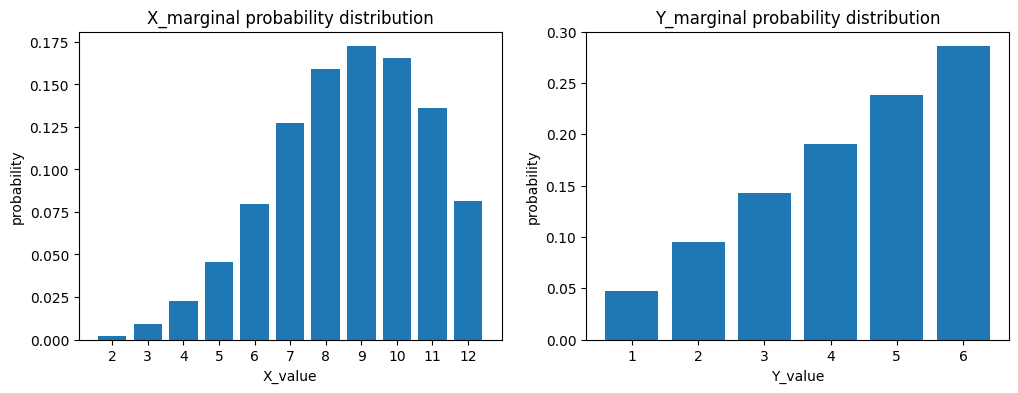

In [29]:
prob_x = np.array([f_X(x_k) for x_k in x_set])
prob_y = np.array([f_Y(y_k) for y_k in y_set])

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.bar(x_set, prob_x)
ax1.set_title('X_marginal probability distribution')
ax1.set_xlabel('X_value')
ax1.set_ylabel('probability')
ax1.set_xticks(x_set)

ax2.bar(y_set, prob_y)
ax2.set_title('Y_marginal probability distribution')
ax2.set_xlabel('Y_value')
ax2.set_ylabel('probability')

plt.show()

In [30]:
#기댓값
np.sum([x_i * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

np.float64(8.666666666666666)

In [31]:
#분산
def E(XY, g):
    x_set, y_set, f_XY = XY
    return np.sum([g(x_i, y_j) * f_XY(x_i, y_j)
                   for x_i in x_set for y_j in y_set])

mean_X = E(XY, lambda x, y: x)
mean_X

np.float64(8.666666666666666)

In [32]:
mean_Y = E(XY, lambda x, y: y)
mean_Y

np.float64(4.333333333333333)

In [33]:
#E(aX + bY)
a, b = 2, 3
E(XY, lambda x, y: a*x + b*y)

np.float64(30.333333333333332)

In [34]:
a * mean_X + b * mean_Y

np.float64(30.333333333333332)

In [35]:
#X의 분산은 X에 관한 편차 제곱의 기댓값
np.sum([(x_i-mean_X)**2 * f_XY(x_i, y_j)
       for x_i in x_set for y_j in y_set])

np.float64(4.444444444444444)

In [36]:
#X, Y의 함수 g(X, Y)의 분산
def V(XY, g):
    x_set, y_set, f_XY = XY
    mean = E(XY, g)
    return np.sum([(g(x_i, y_j)-mean)**2 * f_XY(x_i, y_j)
                   for x_i in x_set for y_j in y_set])

var_X = V(XY, g=lambda x, y: x)
var_X

np.float64(4.444444444444444)

In [37]:
var_Y = V(XY, g=lambda x, y: y)
var_Y

np.float64(2.2222222222222223)

In [38]:
#공분산
def Cov(XY):
    x_set, y_set, f_XY = XY
    mean_X = E(XY, lambda x, y: x)
    mean_Y = E(XY, lambda x, y: y)
    return np.sum([(x_i-mean_X) * (y_j-mean_Y) * f_XY(x_i, y_j)
                    for x_i in x_set for y_j in y_set])

cov_xy = Cov(XY)
cov_xy

np.float64(2.222222222222222)

##### 공분산은 주식에서 많이 쓰임. -> 금융권

In [ ]:
#분산과 공분산 공식
# - a, b를 실수, X, Y를 확률변수라 할 때 V(aX + bY) = a**2V(X) + b**2V(Y) + 2abcov(X, Y)
V(XY, lambda x, y: a*x + b*y)

np.float64(64.44444444444444)

In [40]:
a**2 * var_X + b**2 * var_Y + 2*a*b * cov_xy

np.float64(64.44444444444443)

In [ ]:
#상관계수
cov_xy / np.sqrt(var_X * var_Y)

np.float64(0.7071067811865474)

# ch06 대표적인 이산형 확률변수

- 베르누이 분포

In [3]:
#scipy 설치에 문제가 있을 경우

import sys
import subprocess

# 현재 실행 중인 파이썬의 경로로 직접 scipy 설치 지시
subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])

print("설치 완료! 이제 import scipy를 시도해보세요.")

설치 완료! 이제 import scipy를 시도해보세요.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%precision 3
%matplotlib inline

In [12]:
#모수적 기법
# - '모집단이 이와 같은 성질일 것이므로 이러한 형태를 갖는 확률분포일 것이다.'라고 가정
# - 그 뒤에 확률분포의 기댓값이나 분산을 결정하는 소수의 파라미터 추측

# 그래프 선의 종류
linestyles = ['-', '--', ':']

def E(X, g=lambda x: x):
    x_set, f = X
    return np.sum([g(x_k) * f(x_k) for x_k in x_set])

def V(X, g=lambda x: x):
    x_set, f = X
    mean = E(X, g)
    return np.sum([(g(x_k)-mean)**2 * f(x_k) for x_k in x_set])

def check_prob(X):
    x_set, f = X
    prob = np.array([f(x_k) for x_k in x_set])
    assert np.all(prob >= 0), 'minus probability'
    prob_sum = np.round(np.sum(prob), 6)
    assert prob_sum == 1, f'sum of probability{prob_sum}'
    print(f'expected value {E(X):.4}')
    print(f'variance {(V(X)):.4}')

def plot_prob(X):
    x_set, f = X
    prob = np.array([f(x_k) for x_k in x_set])
    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    ax.bar(x_set, prob, label='prob')
    ax.vlines(E(X), 0, 1, label='mean', colors = 'black')
    ax.set_xticks(np.append(x_set, E(X)))
    ax.set_ylim(0, prob.max()*1.2)
    ax.legend()
    
    plt.show()

In [7]:
#베르누이 분포
# - 확률변수가 취할 수 있는 값이 0(실패), 1(성공)밖에 없는 분포
# - 베르누이 분포를 따르는 확률변수의 시행이 베르누이 시행
# - 1이 나올 확률이 p라면 0이 나올 확률은 1-p
# - p가 파라미터인 베르누이 분포는 Bern(p)

def Bern(p):
    x_set = np.array([0, 1])
    def f(x):
        if x in x_set:
            return p ** x * (1-p) ** (1-x)
        else:
            return 0
    return x_set, f

In [10]:
#베르누이 분포의 기댓값과 분산 : X ~ Bern(p)라고 할 때
# E(X) = p, V(x) = p(1-p)

#예> X ~ Bern(0.3)
p = 0.3
X = Bern(p)

check_prob(X)

expected value 0.3
variance 0.21


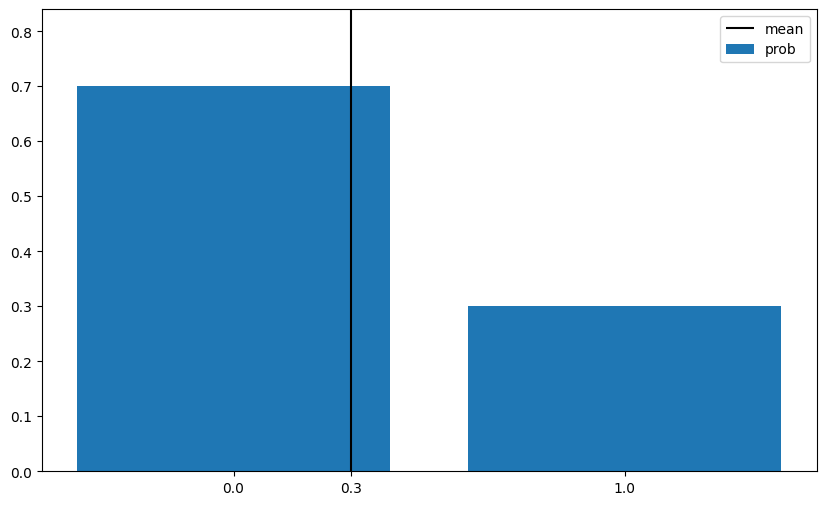

In [13]:
plot_prob(X)

In [14]:
#scipy.stats의 bernoulli 함수는 베르누이 분포를 따르는 확률변수 생성
rv = stats.bernoulli(p)

#pmf 메서드는 확률함수 계산
rv.pmf(0), rv.pmf(1)

(0.700, 0.300)

In [15]:
rv.pmf([0, 1])

array([0.7, 0.3])

In [16]:
#cdf 메서드는 누적밀도함수 계산
rv.cdf([0, 1])

array([0.7, 1. ])

In [17]:
#mean, var 메서드로 기댓값, 분산 계산
rv.mean(), rv.var()

(0.300, 0.210)

##### ---------------------------------
<베르누이의 분포 정리>
- 파라미터 : p
- 취할 수 있는 값 : {0,1}
- 확률함수 : p^x(1-p)^(1-x)
- 기댓값 : p
- 분산 : p(1-p)
- scipy.stats : bernoulli(p)
##### ---------------------------------

- 이항분포

In [19]:
#이항분포: 성공 확률이 p인 베르누이 시행을 n번 했을 때의 성공 횟수가 따르는 분포
# - 파라미터 n, p인 이항분포는 Bin(n,p)

#이항분포의 기댓값과 분산: X~ Bin(n,p)라 할 때
# - E(x) = np, V(X) = np(1-p)
from scipy.special import comb

def Bin(n, p):
    x_set = np.arange(n+1)
    def f(x):
        if x in x_set:
            return comb(n, x) * p**x * (1-p)**(n-x)
        else:
            return 0
    return x_set, f

#예> X~ Bin(10, 0.3)
n = 10
p = 0.3
X = Bin(n, p)

check_prob(X)

expected value 3.0
variance 2.1


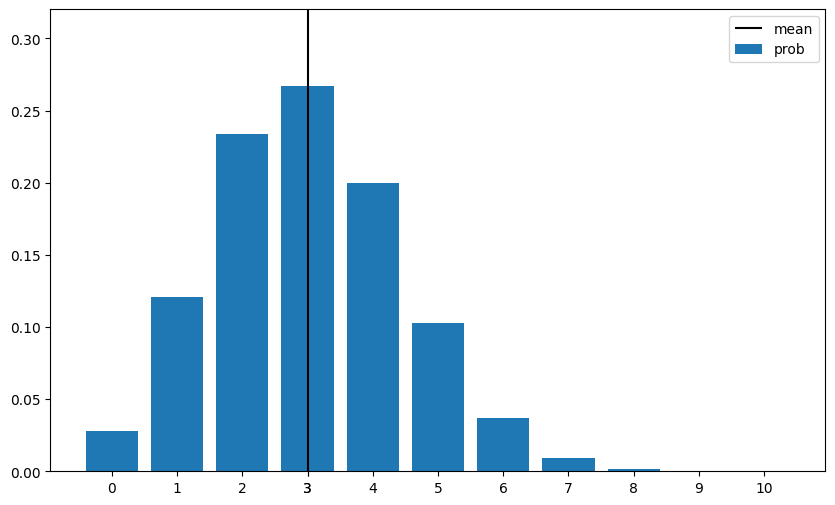

In [20]:
plot_prob(X)

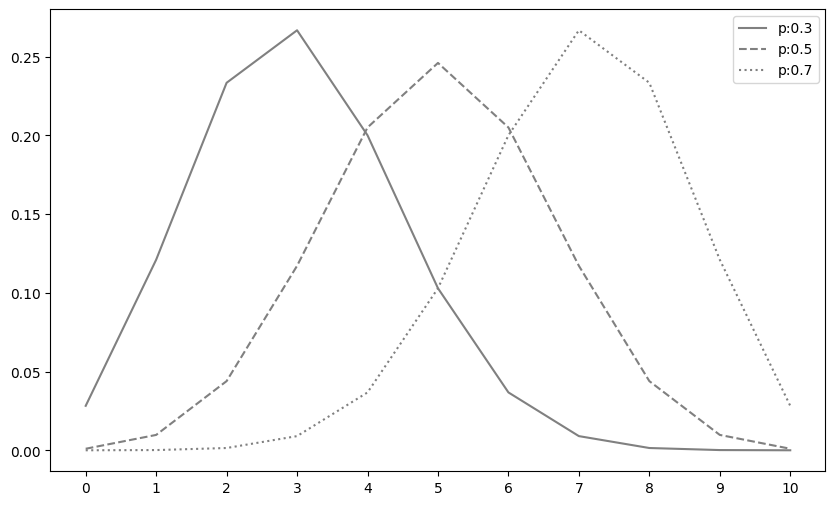

In [21]:
#scipy.stats의 binom 함수는 이항분포를 따르는 확률변수 생성
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

x_set = np.arange(n+1)
for p, ls in zip([0.3, 0.5, 0.7], linestyles):
    rv = stats.binom(n, p)
    ax.plot(x_set, rv.pmf(x_set),
            label=f'p:{p}', ls=ls, color='gray')
ax.set_xticks(x_set)
ax.legend()

plt.show()

##### ---------------------------------
<이항분포의 정리>
- 파라미터 : n, p
- 취할 수 있는 값 : {0,1, ...., n}
- 확률함수 : n Combination xp*x(1-p)^(1-x)
- 기댓값 : np
- 분산 : np(1-p)
- scipy.stats : binom(n, p)
##### ---------------------------------

- 기하분포

In [ ]:
#기하분포: 베르누이 시행에서 처음 성공할 때까지 반복한 시행 횟수가 따르는 분포
# - 파라미터 p인 기하분포는 Ge(p)

#기하분포의 기댓값과 분산: X~Ge(p)라 할 때,
# - E(X) = 1/p, V(X) = (1-p)/p**2
def Ge(p):
    x_set = np.arange(1, 30)
    def f(x):
        if x in x_set:
            return p * (1-p) ** (x-1)
        else:
            return 0
    return x_set, f

#예> X~Ge(1/2)
p = 0.5
X = Ge(p)

check_prob(X)

expected value 2.0
variance 2.0


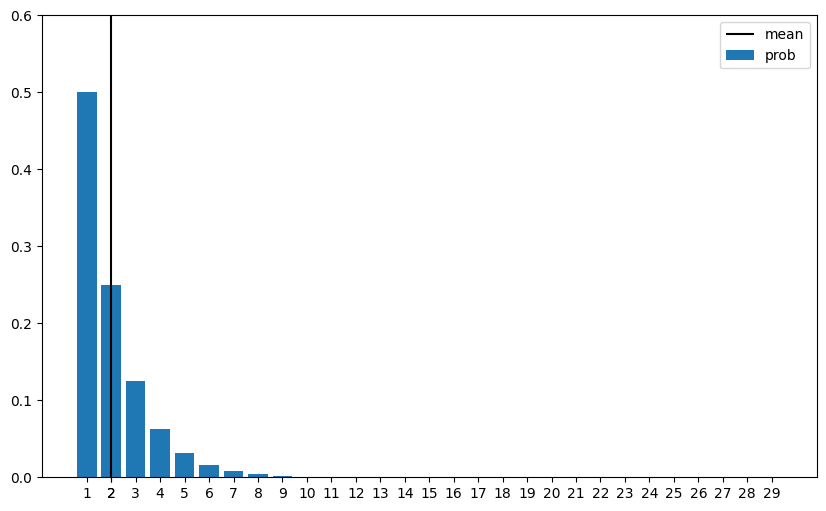

In [23]:
plot_prob(X)

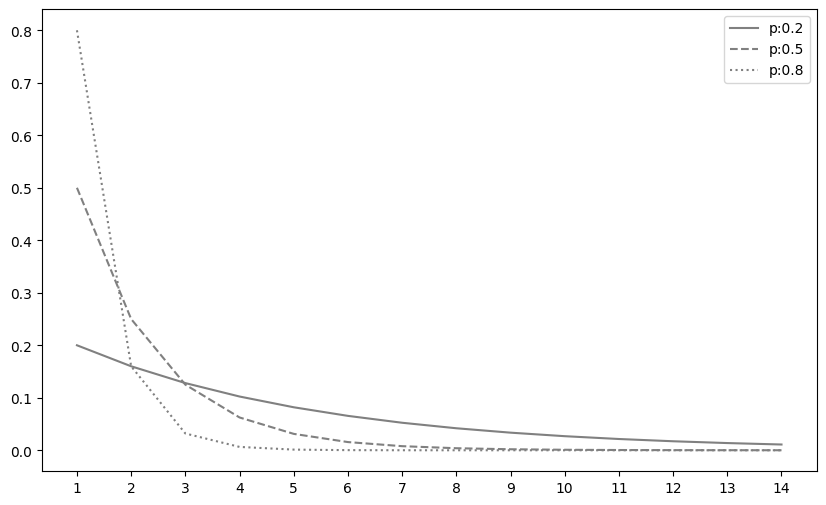

In [ ]:
#다양한 파라미터의 기하분포

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

x_set = np.arange(1, 15)
for p, ls in zip([0.2, 0.5, 0.8], linestyles):
    rv = stats.geom(p)
    ax.plot(x_set, rv.pmf(x_set),
            label=f'p:{p}', ls=ls, color='gray')
ax.set_xticks(x_set)
ax.legend()

plt.show()

##### ---------------------------------
<기하분포의 정리>
- 파라미터 : p
- 취할 수 있는 값 : {1, 2, 3,....}
- 확률함수 : (1-p)^(x-1)p
- 기댓값 : 1/p
- 분산 : (1-p)/p**2
- scipy.stats : geom(p)
##### ---------------------------------

- 포아송 분포

In [25]:
#포아송 분포: 임의의 사건이 단위 시간당 발생하는 건수가 따르는 확률분포
# - 파라미터 lambda인 포아송 분포는 Poi(lambda)
#Poi(lambda)는 단위 시간당 평균 lambda번 발생하는 임의의 사건이 단위 시간에 발생하는 건수가 따르는 분포

# => '시간당 n번' 발생하는 사건이 시간당 '몇 번' 발생하는가? 여부임

#포아송 분포의 기댓값과 분산: X~Poi(lambda)라고 할 때,
# - E(X) = lambda, V(X) = lambda
from scipy.special import factorial

def Poi(lam):
    x_set = np.arange(20)
    def f(x):
        if x in x_set:
            return np.power(lam, x) / factorial(x) * np.exp(-lam)
        else:
            return 0
    return x_set, f

#예> Poi(3)
lam = 3
X = Poi(lam)

check_prob(X)

expected value 3.0
variance 3.0


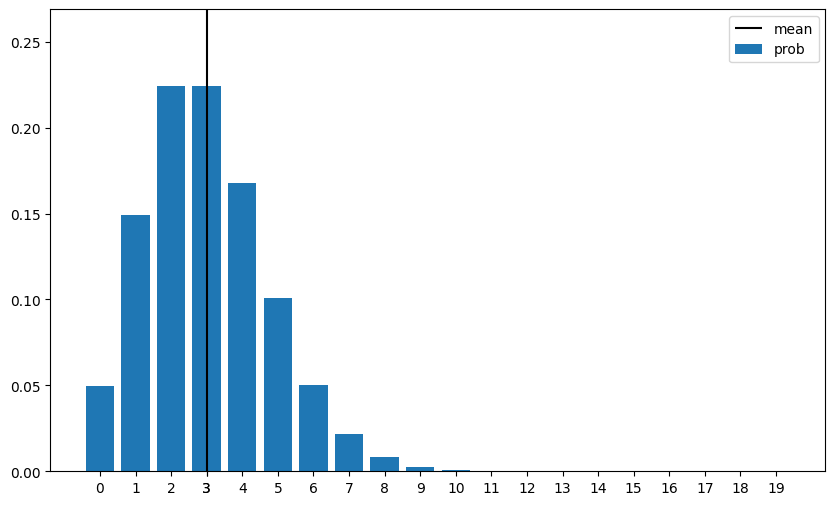

In [26]:
plot_prob(X)

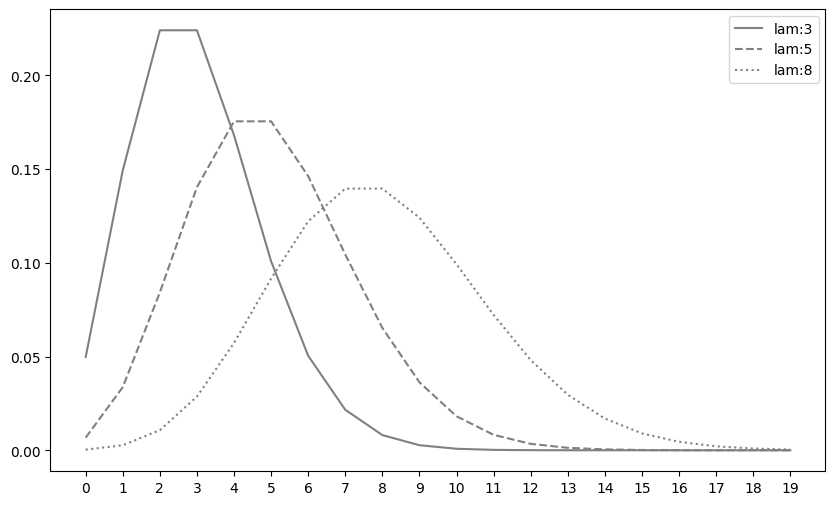

In [28]:
#람다가 커질수록 평균과 분산도 같이 커짐 -> 그래프가 '오른쪽(평균증가)'으로 '넓어지는(분산증가)' 그래프

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

x_set = np.arange(20)
for lam, ls in zip([3, 5, 8], linestyles):
    rv = stats.poisson(lam)
    ax.plot(x_set, rv.pmf(x_set),
            label=f'lam:{lam}', ls=ls, color='gray')
ax.set_xticks(x_set)
ax.legend()

plt.show()

##### ---------------------------------
<포아송 분포의 정리>
- 파라미터 : lambda
- 취할 수 있는 값 : {0, 1, 2, 3,....}
- 확률함수 : lambda**x / x! * e ** (-lambda)
- 기댓값 : lambda
- 분산 : lambda
- scipy.stats : poisson(lambda)
##### ---------------------------------

## 연습문제 - 품질검사 데이터 분석

1. 필요한 그래프 그려보기
 - 제품 1개 단위 - 불량 여부 분포
 - 하루 생산량 분포
 - 하루 불량 개수 분포(x-하루 불량 개수, y-빈도)
 - 하루불량개수 vs 날짜
 - 이론 분포 vs 실제 데이터

2. 답변해야 하는 내용
 - 제품 1개의 불량 여부, 하루동안의 불량 제품 개수가 각각 어떤 분포를 따르는지 설명
 - 데이터를 이용해 lambda를 추정

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

%precision 3
%matplotlib inline
pd.set_option('display.float_format', '{:.3f}'.format)

In [16]:
#아래는 한글을 사용할 때 깨지는 문제에 대한 해결
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family=font_name)

#그래프의 축 등에서 음수를 표시할 때 minus sign이 깨지는 것 해결
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

In [17]:
df = pd.read_csv('../통계분석2/받은 파일/data/quality_inspection.csv')
df

,date,product_id,line,shift,inspector,inspected,defect,machine temp,dow
0,2025-10-28,P127143,C,day,kim,Y,0,89.0,1
1,2025-12-06 00:00:00,P167273,A,day,han,1,0,84.37,5
2,2025-11-23,P153356,A,day,park,Y,0,86.1,6
3,2025-11-15,P145037,A,day,seo,N,NaN,83.46,5
4,2025-10-21,P121440,B,day,jung,Y,0,77.0,1
...,...,...,...,...,...,...,...,...,...
93183,2025.10.31,P130125,B,night,park,True,0,87.2C,4
93184,2025-11-30,P160961,A,day,park,True,0,81.76,6
93185,12-25-2025,P186080,A,day,choi,True,0,87.73,3
93186,2025-10-29,P128940,b,day,park,Y,0,73.6,2


In [18]:
df['date'].unique()

array(['2025-10-28', '2025-12-06 00:00:00', '2025-11-23', '2025-11-15',
       '2025-10-21', '2025-12-14', '2025-11-15 00:00:00', '2025-10-31',
       '2025-12-20', '2025-11-10 00:00:00', '2025-12-26', '2025-10-11',
       '10-15-2025', '2025-10-13', '10-10-2025', '2025.12.03',
       '2025.10.18', '2025-10-02', '2025/11/05', '2025/10/22',
       '2025-12-07', '12-01-2025', '2025-12-31', '2025-11-25',
       '2025-12-04', '2025/11/10', '2025/11/02', '2025/10/20',
       '12-20-2025', '2025-12-26 00:00:00', '10-11-2025', '2025/12/29',
       '2025/11/01', '2025/11/12', '11-03-2025', '2025-11-12',
       '2025/11/29', '10-20-2025', '2025-11-27', '2025-12-21 00:00:00',
       '11-18-2025', '2025-10-29', '2025/10/01', '2025-12-19',
       '2025.10.12', '2025.11.04', '2025-10-20', '2025-12-18',
       '2025-12-27 00:00:00', '2025-11-19', '10-27-2025', '12-26-2025',
       '2025-12-29 00:00:00', '2025-11-20', '2025/12/31', '12-25-2025',
       '2025/11/18', '2025-12-01', '2025/11/27', '12-06

In [19]:
temp_dt = pd.to_datetime(df['date'], yearfirst=True, errors='coerce')
df['date_to'] = df['date'].str.replace(r'\s.*', '', regex=True)

df['date_year'] = temp_dt.dt.year.astype('Int64')
df['date_month'] = temp_dt.dt.month.astype('Int64')
df['date_day'] = temp_dt.dt.day.astype('Int64')

df

,date,product_id,line,shift,inspector,inspected,defect,machine temp,dow,date_to,date_year,date_month,date_day
0,2025-10-28,P127143,C,day,kim,Y,0,89.0,1,2025-10-28,2025,10,28
1,2025-12-06 00:00:00,P167273,A,day,han,1,0,84.37,5,2025-12-06,<NA>,<NA>,<NA>
2,2025-11-23,P153356,A,day,park,Y,0,86.1,6,2025-11-23,2025,11,23
3,2025-11-15,P145037,A,day,seo,N,NaN,83.46,5,2025-11-15,2025,11,15
4,2025-10-21,P121440,B,day,jung,Y,0,77.0,1,2025-10-21,2025,10,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93183,2025.10.31,P130125,B,night,park,True,0,87.2C,4,2025.10.31,<NA>,<NA>,<NA>
93184,2025-11-30,P160961,A,day,park,True,0,81.76,6,2025-11-30,2025,11,30
93185,12-25-2025,P186080,A,day,choi,True,0,87.73,3,12-25-2025,<NA>,<NA>,<NA>
93186,2025-10-29,P128940,b,day,park,Y,0,73.6,2,2025-10-29,2025,10,29


In [20]:
df['product_id'].unique() #2146개 중복

array(['P127143', 'P167273', 'P153356', ..., 'P186080', 'P128940',
       'P137105'], shape=(91042,), dtype=object)

In [21]:
df = df.sort_values(by='product_id', ascending=True)
df.drop_duplicates(subset=['product_id'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"남은 데이터 건수: {len(df)}")
df

남은 데이터 건수: 91042


,date,product_id,line,shift,inspector,inspected,defect,machine temp,dow,date_to,date_year,date_month,date_day
0,2025-10-01,P100000,B,night,yoon,0,NaN,89.38,2,2025-10-01,2025,10,1
1,2025/10/01,P100001,A,day,kim,1,0,87.6C,2,2025/10/01,<NA>,<NA>,<NA>
2,2025.10.01,P100002,A,day,park,T,X,75.56,2,2025.10.01,<NA>,<NA>,<NA>
3,10-01-2025,P100003,B,night,kim,Y,0,75.0,2,10-01-2025,<NA>,<NA>,<NA>
4,2025-10-01,P100004,A,day,kim,yes,0,77.6C,2,2025-10-01,2025,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91037,12-31-2025,P192812,A,day,lee,1,정상,72.07,2,12-31-2025,<NA>,<NA>,<NA>
91038,2025/12/31,P192813,B,day,kim,1,0,79.9,2,2025/12/31,<NA>,<NA>,<NA>
91039,2025/12/31,P192815,A,day,choi,1,0,74.95,2,2025/12/31,<NA>,<NA>,<NA>
91040,2025-12-31,P192816,B,day,han,Y,0,82.91,2,2025-12-31,2025,12,31


In [22]:
df['line'].unique()

array(['B', 'A', 'B ', 'C', nan, ' B', 'b', 'D', 'A ', ' A', 'C-', ' C',
       'a', 'C ', 'c'], dtype=object)

In [23]:
line_map = {
    'C': 'C',
    'C ': 'C',
    'C-': 'C',
    'c': 'C',
    ' C': 'C',
    'A': 'A',
    ' A': 'A',
    'A ': 'A',
    'a': 'A',
    'B': 'B',
    'b': 'B',
    'B ': 'B',
    ' B': 'B',
    'D': ''
}
df['clean_line'] = df['line'].replace(line_map)

df['clean_line'].unique()

array(['B', 'A', 'C', nan, ''], dtype=object)

In [24]:
df['shift'].unique()

array(['night', 'day', 'Day', nan, 'nigth', 'Night', ' night', 'day '],
      dtype=object)

In [25]:
shift_map = {
    'day': 'Day',
    'Day': 'Day',
    'day ': 'Day',
    'night': 'Night',
    'Night': 'Night',
    ' night': 'Night',
    'nigth': 'Night',
}
df['clean_shift'] = df['shift'].replace(shift_map)

df['clean_shift'].unique()

array(['Night', 'Day', nan], dtype=object)

In [26]:
df['inspector'].unique()

array(['yoon', 'kim', 'park', 'choi', 'han', 'jung', 'seo', 'lee', 'JUNG',
       'YOON', nan, 'SEO', 'LEE', 'prak', 'jng', 'PARK', 'HAN', 'CHOI',
       'cho1', 'KIM', 'yo0n', 'CHO1', 'PRAK', 'JNG', 'YO0N'], dtype=object)

In [27]:
tor_map = {
    'kim': 'Kim',
    'KIM': 'Kim',
    'han': 'Han',
    'HAN': 'Han',
    'park': 'Park',
    'PARK': 'Park',
    'prak': 'Park',
    'PRAK': 'Park',
    'seo': 'Seo',
    'SEO': 'Seo',
    'jung': 'Jung',
    'jng': 'Jung',
    'JUNG': 'Jung',
    'JNG': 'Jung',
    'yoon': 'Yoon',
    'yo0n': 'Yoon',
    'YOON': 'Yoon',
    'YO0N': 'Yoon',
    'lee': 'Lee',
    'LEE': 'Lee',
    'choi': 'Choi',
    'cho1': 'Choi',
    'CHOI': 'Choi',
    'CHO1': 'Choi',
}
df['clean_inspector'] = df['inspector'].replace(tor_map)

df['clean_inspector'].unique()

array(['Yoon', 'Kim', 'Park', 'Choi', 'Han', 'Jung', 'Seo', 'Lee', nan],
      dtype=object)

In [28]:
df['inspected'].unique()

array(['0', '1', 'T', 'Y', 'yes', 'True', 'False', 'N', 'no', nan, 'F'],
      dtype=object)

In [ ]:
ted_map = {
    'Y': 1,
    '1': 1,
    'N': 0,
    'yes': 1,
    '0': 0,
    'True': 1,
    'T': 1,
    'no': 0,
    'F': 0,
    'False': 0,
} #True가 1, False가 0
df['clean_inspected'] = df['inspected'].replace(ted_map)

df['clean_inspected'].unique()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9436\3496258867.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['clean_inspected'] = df['inspected'].replace(ted_map)


array([ 0.,  1., nan])

In [30]:
df['defect'].unique()

array([nan, '0', 'X', '정상', '1', '불량', 'O'], dtype=object)

In [ ]:
def_map = {
    '0': 0,
    'X': 1,
    '정상': 0,
    'O': 0,
    '1': 1,
    '불량': 1,
} #정상이 0, 불량이 1
df['clean_defect'] = df['defect'].replace(def_map)

df['clean_defect'].unique()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9436\627786629.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['clean_defect'] = df['defect'].replace(def_map)


array([nan,  0.,  1.])

In [32]:
df['machine temp'].unique()

array(['89.38', '87.6C', '75.56', ..., '48.13', '54.5C', '49.3C'],
      shape=(6150,), dtype=object)

In [33]:
len(df['machine temp'])

91042

In [34]:
df['clean_machine_temp'] = df['machine temp'].copy()
df['clean_machine_temp'] = df['machine temp'].astype(str).str.replace(r'[^0-9.]', '', regex=True).str.strip()
df['clean_machine_temp'] = pd.to_numeric(df['clean_machine_temp'], errors='coerce')
df['clean_machine_temp'].head(50)

0    89.380
1    87.600
2    75.560
3    75.000
4    77.600
5    84.400
6    75.530
7    70.830
8    80.250
9    64.590
10   78.930
11   85.550
12   80.000
13   83.080
14   81.220
15   82.740
16   78.950
17   72.610
18   76.540
19   77.520
20   86.180
21   63.570
22   80.700
23   73.110
24   73.300
25   76.800
26   87.030
27   80.170
28   77.640
29   73.030
30      NaN
31   79.880
32   77.670
33   78.670
34   88.960
35   77.000
36   88.970
37   86.070
38   78.340
39   83.750
40   77.200
41   72.620
42   76.260
43   72.100
44   81.320
45   78.100
46   81.690
47   83.370
48   57.720
49   80.020
Name: clean_machine_temp, dtype: float64

In [35]:
df['dow'].unique()

array(['2', 'Wed', '3', '4', 'Thu', 'Fri', '5', 'Sat', '6', 'Sun', '7',
       '0', 'Mon', '1', 'Tue'], dtype=object)

In [36]:
dow_map = {
    '1': 1,
    '5': 5,
    '6': 6,
    '4': 4,
    '0': 0,
    '2': 2,
    '3': 3,
    'Sat': 5,
    'Thu': 3,
    'Sun': 6,
    'Fri': 4,
    '7': 6,
    'Tue': 1,
    'Mon': 0,
    'Wed': 2,
}
df['clean_dow'] = df['dow'].replace(dow_map)

df['clean_dow'].unique()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9436\1208130775.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['clean_dow'] = df['dow'].replace(dow_map)


array([2, 3, 4, 5, 6, 0, 1])

In [38]:
df2 = pd.DataFrame(df[['date_to', 'date_year', 'date_month', 'date_day', 'product_id', 'clean_line', 'clean_shift', 'clean_inspector', 'clean_inspected', 'clean_defect', 'clean_machine_temp', 'clean_dow']])
df2

,date_to,date_year,date_month,date_day,product_id,clean_line,clean_shift,clean_inspector,clean_inspected,clean_defect,clean_machine_temp,clean_dow
0,2025-10-01,2025,10,1,P100000,B,Night,Yoon,0.000,NaN,89.380,2
1,2025/10/01,<NA>,<NA>,<NA>,P100001,A,Day,Kim,1.000,0.000,87.600,2
2,2025.10.01,<NA>,<NA>,<NA>,P100002,A,Day,Park,1.000,1.000,75.560,2
3,10-01-2025,<NA>,<NA>,<NA>,P100003,B,Night,Kim,1.000,0.000,75.000,2
4,2025-10-01,2025,10,1,P100004,A,Day,Kim,1.000,0.000,77.600,2
...,...,...,...,...,...,...,...,...,...,...,...,...
91037,12-31-2025,<NA>,<NA>,<NA>,P192812,A,Day,Lee,1.000,0.000,72.070,2
91038,2025/12/31,<NA>,<NA>,<NA>,P192813,B,Day,Kim,1.000,0.000,79.900,2
91039,2025/12/31,<NA>,<NA>,<NA>,P192815,A,Day,Choi,1.000,0.000,74.950,2
91040,2025-12-31,2025,12,31,P192816,B,Day,Han,1.000,0.000,82.910,2


In [64]:
df2 = df2.dropna()
df2

,date_to,date_year,date_month,date_day,product_id,clean_line,clean_shift,clean_inspector,clean_inspected,clean_defect,clean_machine_temp,clean_dow
4,2025-10-01,2025,10,1,P100004,A,Day,Kim,1.000,0.000,77.600,2
7,2025-10-01,2025,10,1,P100007,B,Day,Han,1.000,0.000,70.830,2
12,2025-10-01,2025,10,1,P100012,B,Day,Park,1.000,1.000,80.000,2
14,2025-10-01,2025,10,1,P100014,C,Day,Lee,1.000,0.000,81.220,2
15,2025-10-01,2025,10,1,P100015,B,Day,Kim,1.000,0.000,82.740,2
...,...,...,...,...,...,...,...,...,...,...,...,...
91025,2025-12-31,2025,12,31,P192800,A,Night,Jung,1.000,0.000,77.270,2
91030,2025-12-31,2025,12,31,P192805,B,Day,Seo,1.000,0.000,74.160,2
91031,2025-12-31,2025,12,31,P192806,A,Day,Han,1.000,0.000,72.010,2
91036,2025-12-31,2025,12,31,P192811,B,Night,Han,1.000,1.000,71.500,2


In [44]:
! python -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [66]:
# 데이터 집계: 날짜별 총 생산량 및 불량 개수
daily_stats = df2.groupby('date_to')['clean_defect'].agg(['count', 'sum']).rename(
    columns={'count': 'total_prod', 'sum': 'defect_count'}
)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9436\1127718682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='clean_defect', data=df2, palette='Set2')


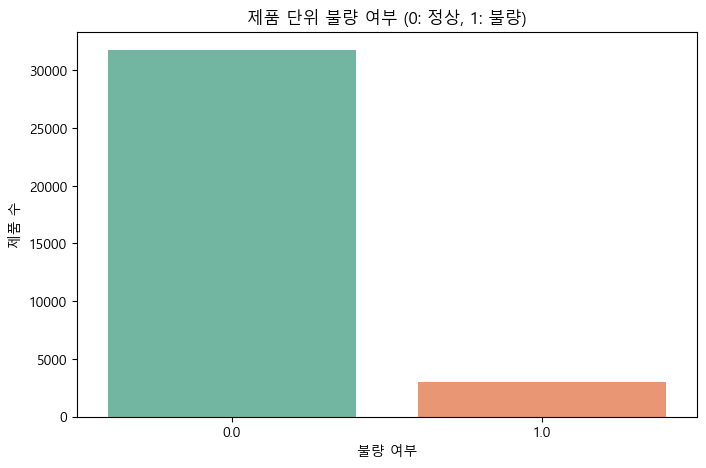

In [75]:
# --- 그래프 1: 제품 1개 단위 - 불량 여부 분포 ---
plt.figure(figsize=(8, 5))
sns.countplot(x='clean_defect', data=df2, palette='Set2')
plt.title('제품 단위 불량 여부 (0: 정상, 1: 불량)')
plt.xlabel('불량 여부')
plt.ylabel('제품 수')
plt.show()

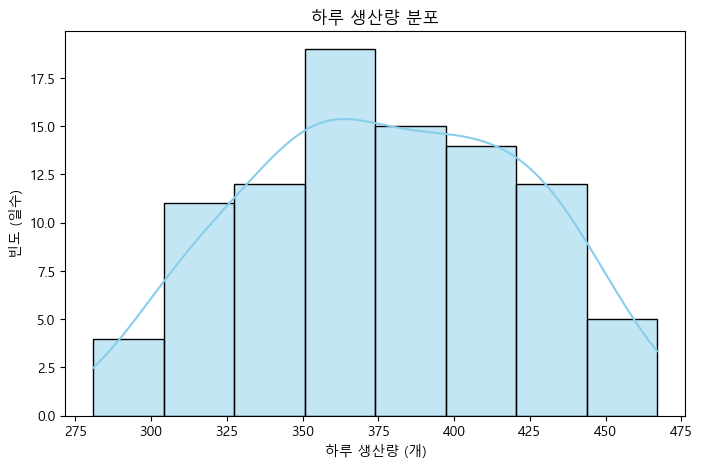

In [76]:
# --- 그래프 2: 하루 생산량 분포 ---
plt.figure(figsize=(8, 5))
sns.histplot(daily_stats['total_prod'], kde=True, color='skyblue')
plt.title('하루 생산량 분포')
plt.xlabel('하루 생산량 (개)')
plt.ylabel('빈도 (일수)')
plt.show()

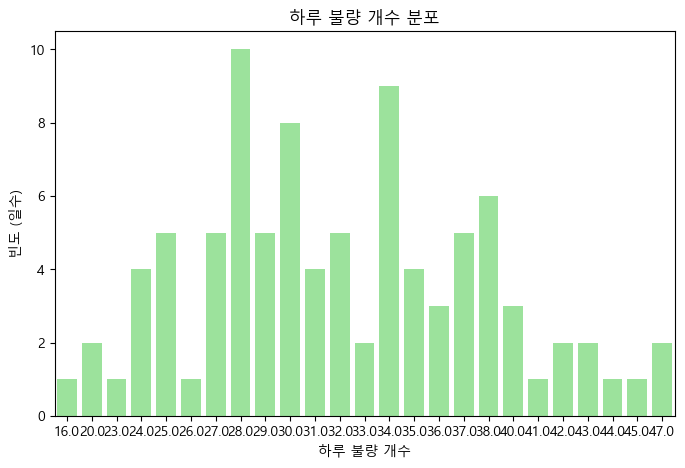

In [77]:
# --- 그래프 3: 하루 불량 개수 분포 (x: 불량 개수, y: 빈도) ---
plt.figure(figsize=(8, 5))
sns.countplot(x='defect_count', data=daily_stats, color='lightgreen')
plt.title('하루 불량 개수 분포')
plt.xlabel('하루 불량 개수')
plt.ylabel('빈도 (일수)')
plt.show()

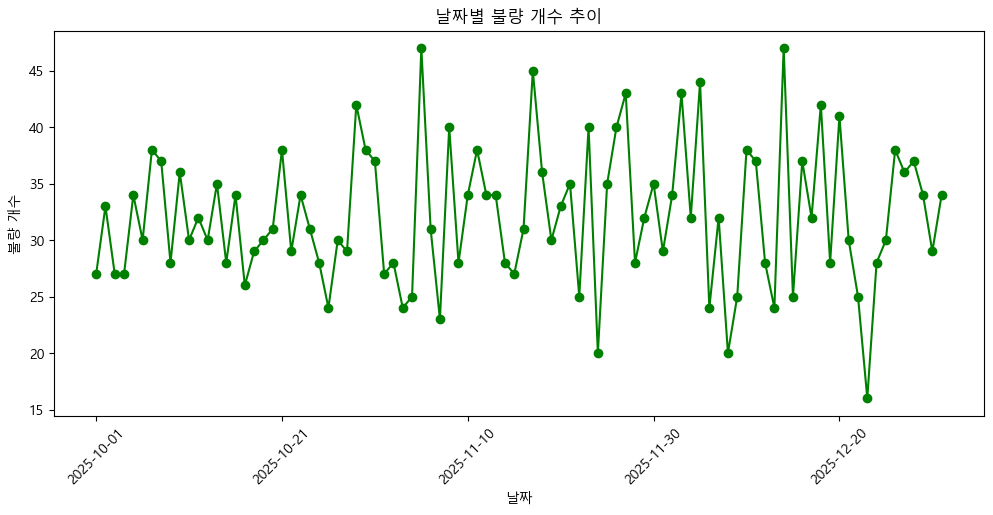

In [78]:
# --- 그래프 4: 하루 불량 개수 vs 날짜 ---
plt.figure(figsize=(12, 5))
daily_stats['defect_count'].plot(marker='o', color='green', linestyle='-')
plt.title('날짜별 불량 개수 추이')
plt.xlabel('날짜')
plt.ylabel('불량 개수')
plt.xticks(rotation=45)
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9436\2503205334.py:11: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_range, poisson_pmf, 'ro--', label=f'포아송 비($\lambda$={mu_lambda:.2f})')


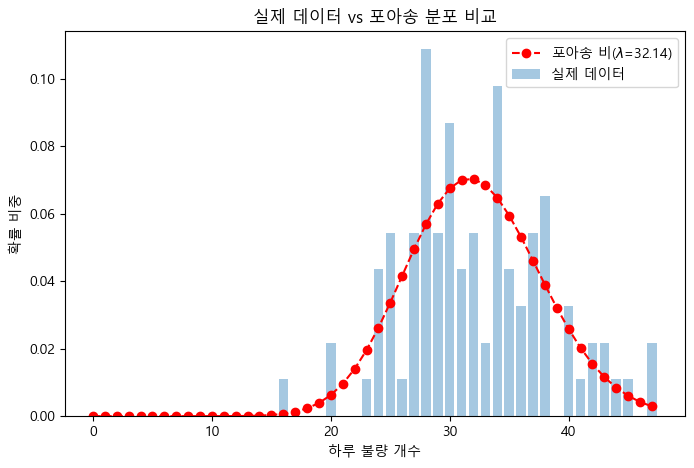

In [ ]:
# --- 그래프 5: 이론 분포 vs 실제 데이터 ---
plt.figure(figsize=(8, 5))
mu_lambda = daily_stats['defect_count'].mean() # 람다 추정
x_range = np.arange(0, daily_stats['defect_count'].max() + 1)
poisson_pmf = stats.poisson.pmf(x_range, mu_lambda)

# 실제 데이터 비율
actual_dist = daily_stats['defect_count'].value_counts(normalize=True).sort_index()
plt.bar(actual_dist.index, actual_dist.values, alpha=0.4, label='실제 데이터')

# 이론적 포아송 분포
plt.plot(x_range, poisson_pmf, 'ro--', label=f'포아송 비($\lambda$={mu_lambda:.2f})')
plt.title('실제 데이터 vs 포아송 분포 비교')
plt.xlabel('하루 불량 개수')
plt.ylabel('확률 비중')
plt.legend()
plt.show()